# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [17]:
# Standard library imports
import os
import sys
import copy
from typing import Optional


# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course', 'src') #changed for Macbook
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [18]:
PATH_TO_DATA = '../data_backtesting_assignment3/' # <CHANGE THIS TO YOUR PATH TO DATA> 

In [19]:

# Load market and jkp data from parquet files
import pyarrow.parquet as pq

table_market = pq.read_table(f"{PATH_TO_DATA}market_data.parquet")
table_jkp = pq.read_table(f"{PATH_TO_DATA}jkp_data.parquet")

market_data = table_market.to_pandas(strings_to_categorical=False)
jkp_data = table_jkp.to_pandas(strings_to_categorical=False) #dati per costruire factors 

# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [20]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [21]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 max_iter: int = 10,
                 tol: float = 1e-6,
                 **kwargs):
        super().__init__(
            constraints=constraints,
            max_iter=max_iter,
            tol=tol,
            **kwargs
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        self.mu = np.asarray(self.expected_return.estimate(X=X, inplace=False), dtype=float).reshape(-1)
        self.Sigma = np.asarray(self.covariance.estimate(X=X, inplace=False), dtype=float)

        self.objective = Objective(
            q=-self.mu,
            P=2 * self.Sigma,
        )
        return None

    def solve(self) -> None:
        gamma = 1.0
        best_sr = -np.inf
        best_weights = None
        best_ret = None
        best_vol = None

        ids = self.constraints.ids

        for _ in range(self.params['max_iter']):
            self.objective = Objective(
                q=-self.mu,
                P=2 * gamma * self.Sigma,
            )

            super().solve()

            if not self.results['status']:
                break

            w_dict = self.results['weights']
            w = np.array([w_dict[i] for i in ids], dtype=float)

            port_ret = float(self.mu @ w)
            port_var = float(w @ self.Sigma @ w)

            if port_var <= 1e-12:
                break

            port_vol = np.sqrt(port_var)
            sharpe = port_ret / port_vol

            if sharpe > best_sr:
                best_sr = sharpe
                best_weights = w_dict.copy()
                best_ret = port_ret
                best_vol = port_vol

            new_gamma = port_ret / (2 * port_var)

            if abs(new_gamma - gamma) < self.params['tol']:
                break

            gamma = new_gamma

        self.results.update({
            'weights': best_weights,
            'status': best_weights is not None,
            'expected_return': best_ret,
            'volatility': best_vol,
            'sharpe_ratio': best_sr,
        })

        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [22]:
bs.optimization = MaxSharpe(
   covariance=Covariance(method='pearson'),
     expected_return=ExpectedReturn(method='geometric'),
     solver_name='cvxopt',  # <change this to your preferred solver>
     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
)
bs.prepare_rebalancing(rebdates[-1])
bs.optimization.set_objective(bs.optimization_data)
bs.optimization.solve()

bs.optimization.results
sr_ms = bs.optimization.results['sharpe_ratio']
w_ms = bs.optimization.results['weights']

print("MaxSharpe Sharpe ratio:", sr_ms)
gammas = np.logspace(-2, 2, 50)
grid_sharpes = []

cons = bs.optimization.constraints
X = bs.optimization_data['return_series']
asset_names = list(X.columns)

mu = np.asarray(ExpectedReturn(method='geometric').estimate(X=X, inplace=False)).reshape(-1)
Sigma = np.asarray(Covariance(method='pearson').estimate(X=X, inplace=False))

for g in gammas:
    mv = MeanVariance(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        constraints=cons,
        risk_aversion=g,
        solver_name='cvxopt',
    )

    mv.set_objective(bs.optimization_data)
    mv.solve()

    raw_w = mv.results['weights']

    if isinstance(raw_w, dict):
        w = np.array([raw_w[a] for a in asset_names], dtype=float)
    else:
        w = np.asarray(raw_w, dtype=float).reshape(-1)

    port_ret = float(mu @ w)
    port_vol = float(np.sqrt(w.T @ Sigma @ w))
    sr = port_ret / port_vol
    grid_sharpes.append(sr)

print("Best Sharpe on MV grid:", max(grid_sharpes))
print("Sharpe from MaxSharpe:", bs.optimization.results['sharpe_ratio'])


MaxSharpe Sharpe ratio: 0.06358081985760669
Best Sharpe on MV grid: 0.06357749348543912
Sharpe from MaxSharpe: 0.06358081985760669


We justify convergence empirically,running the iterative MaxSharpe algorithm for one rebalancing date and compare the resulting Sharpe ratio with the highest Sharpe ratio obtained from a broad grid of standard mean-variance optimizations with different values of the risk-aversion parameter.
In our test, the iterative algorithm returns a Sharpe ratio of 0.0635808, while the best Sharpe ratio found on the mean-variance grid is 0.0635775. The difference found is numerically negligible.
Therefore, the iterative procedure converges to the true maximum Sharpe ratio portfolio (or an extremely close numerical approximation of it) for the given estimates of expected returns and covariance.

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [23]:
## 2. Backtest MaxSharpe with Turnover Penalty

target_turnover = 1.00   # 100%
rebdates_calib = bs.settings['rebdates'][:8]

def annual_turnover_from_tau(tau, bs, rebdates_subset):
    rebdates_original = bs.settings['rebdates']
    bs.settings['rebdates'] = rebdates_subset

    bs.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        turnover_penalty=float(tau),
    )

    bt_tmp = Backtest()
    bt_tmp.run(bs=bs)

    return_series_tmp = bs.data.get_return_series(weekdays_only=False)

    turnover_series = bt_tmp.strategy.turnover(
        return_series=return_series_tmp,
        rescale=False
    ).dropna()

    annual_turnover = turnover_series.mean() * 4 if len(turnover_series) > 0 else np.nan

    bs.settings['rebdates'] = rebdates_original
    return annual_turnover

# Step 1: coarse grid
tau_grid = np.logspace(-8, -2, 25)
grid_results = []

for tau in tau_grid:
    annual_to = annual_turnover_from_tau(tau, bs, rebdates_calib)
    grid_results.append({
        "tau": tau,
        "annual_turnover": annual_to,
        "annual_turnover_pct": annual_to * 100 if pd.notna(annual_to) else np.nan,
        "distance_to_target": abs(annual_to - target_turnover) if pd.notna(annual_to) else np.nan,
    })

df_grid = pd.DataFrame(grid_results).sort_values("distance_to_target").reset_index(drop=True)
display(df_grid)

tau_ms = float(df_grid.loc[0, "tau"])
print(f"Selected tau from calibration = {tau_ms:.8g}")

# Final full-sample backtest
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    turnover_penalty=tau_ms,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

return_series = bs.data.get_return_series(weekdays_only=False)
to_ms = bt_ms.strategy.turnover(return_series=return_series, rescale=False).dropna()
annual_turnover_ms = to_ms.mean() * 4

print(f"Annual turnover on full sample = {annual_turnover_ms*100:.2f}%")

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31


KeyboardInterrupt: 

In [ ]:
df_tau = pd.DataFrame(results_tau).sort_values("distance_from_target").reset_index(drop=True)

print("TAU CALIBRATION RESULTS")
display(df_tau)

best_tau = float(df_tau.loc[0, "tau"])
best_row = df_tau.loc[0]

print(f"Best tau (closest to 100% annual turnover): {best_tau:.10g}")
print(f"Avg turnover per rebalance: {best_row['avg_turnover_per_rebalance']:.4f}")
print(f"Annual turnover: {best_row['annual_turnover']:.4f}")
print(f"Annual turnover (%): {best_row['annual_turnover_pct']:.2f}%")
print(f"Distance from target: {best_row['distance_from_target']:.4f}")

tau_ms = best_tau

bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',
    turnover_penalty=tau_ms,
)

bt_ms = Backtest()
bt_ms.run(bs=bs)

print(f"Chosen turnover penalty tau_ms = {tau_ms:.10g}")

TAU CALIBRATION RESULTS


,tau,avg_turnover_per_rebalance,annual_turnover,annual_turnover_pct,distance_from_target
0,5.623413e-08,0.187125,0.748501,74.850129,0.251499
1,3.162278e-08,0.187124,0.748498,74.849761,0.251502
2,1.000000e-08,0.187093,0.748373,74.837345,0.251627
3,1.000000e-07,0.187092,0.748369,74.836872,0.251631
4,1.778279e-07,0.187082,0.748330,74.832974,0.251670
5,1.778279e-08,0.187057,0.748228,74.822806,0.251772
6,3.162278e-07,0.187007,0.748027,74.802709,0.251973
7,5.623413e-07,0.186895,0.747579,74.757907,0.252421
8,1.000000e-06,0.186749,0.746995,74.699532,0.253005
9,1.778279e-06,0.186322,0.745289,74.528886,0.254711


Best tau (closest to 100% annual turnover): 5.623413252e-08
Avg turnover per rebalance: 0.1871
Annual turnover: 0.7485
Annual turnover (%): 74.85%
Distance from target: 0.2515
Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing 

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Costs
fixed_costs = 0.01       # 1% p.a.
variable_costs = 0.003   # 0.3% per unit of turnover

# Return series used for simulation
return_series = bs.data.get_return_series(weekdays_only=False)

def simulate_strategy_robust(strategy, return_series, fc=0.0, vc=0.0, n_days_per_year=252):
    """
    Replica Strategy.simulate() ma con gestione robusta degli indici datetime
    e allineamento sicuro dei costi variabili/fissi.
    """
    rebdates = strategy.get_rebalancing_dates()
    ret_list = []

    for i, rebdate in enumerate(rebdates):
        next_rebdate = rebdates[i + 1] if i < len(rebdates) - 1 else return_series.index[-1]

        portfolio = strategy.get_portfolio(rebdate)
        w_float = portfolio.float_weights(
            return_series=return_series,
            end_date=next_rebdate,
            rescale=False
        )

        level = w_float.sum(axis=1)
        ret_tmp = level.pct_change(1)
        ret_list.append(ret_tmp)

    portf_ret = pd.concat(ret_list).sort_index()
    portf_ret = portf_ret[~portf_ret.index.duplicated(keep='first')].dropna()

    # Variable costs
    if vc != 0:
        to = strategy.turnover(return_series=return_series, rescale=False).dropna()
        varcost = to * vc

        # applichiamo i costi solo sulle date comuni
        common_idx = portf_ret.index.intersection(varcost.index)
        portf_ret.loc[common_idx] = portf_ret.loc[common_idx] - varcost.loc[common_idx]

    # Fixed costs
    if fc != 0 and len(portf_ret) > 1:
        n_days = (
            portf_ret.index.to_series().diff().dt.days.fillna(0).astype(int)
        )
        fixcost = pd.Series(
            (1 + fc) ** (n_days / n_days_per_year) - 1,
            index=portf_ret.index
        )
        fixcost.iloc[0] = 0.0
        portf_ret = portf_ret - fixcost

    return portf_ret

# Simulate MaxSharpe strategy robustly
sim_ms = simulate_strategy_robust(
    strategy=bt_ms.strategy,
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

# Benchmark: allineamento pulito sulle stesse date
bm = bs.data.bm_series.copy().squeeze()
bm.index = pd.to_datetime(bm.index)

sim = pd.concat(
    {
        'bm': bm,
        'ms': sim_ms,
    },
    axis=1
).dropna()

sim.head()


,bm,ms
2005-11-01,0.008450,0.000704
2005-11-02,0.002523,0.003214
2005-11-03,0.012788,0.008384
2005-11-04,-0.000703,-0.002397
2005-11-07,0.006225,0.003897


In [ ]:
return_series

id,1,10,100,101,102,103,104,105,106,107,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
1986-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-01-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.032000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.008264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-04-24,NaN,NaN,-0.003846,NaN,0.001387,-0.034426,0.004975,0.012862,NaN,NaN,...,NaN,NaN,NaN,0.009950,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-25,NaN,NaN,-0.023166,NaN,-0.012465,0.001698,-0.017822,-0.025397,NaN,NaN,...,NaN,NaN,NaN,-0.014778,NaN,NaN,NaN,NaN,NaN,NaN
2024-04-26,NaN,NaN,0.003953,NaN,0.011220,0.025424,0.043347,-0.003257,NaN,NaN,...,NaN,NaN,NaN,0.013750,NaN,NaN,NaN,NaN,NaN,NaN


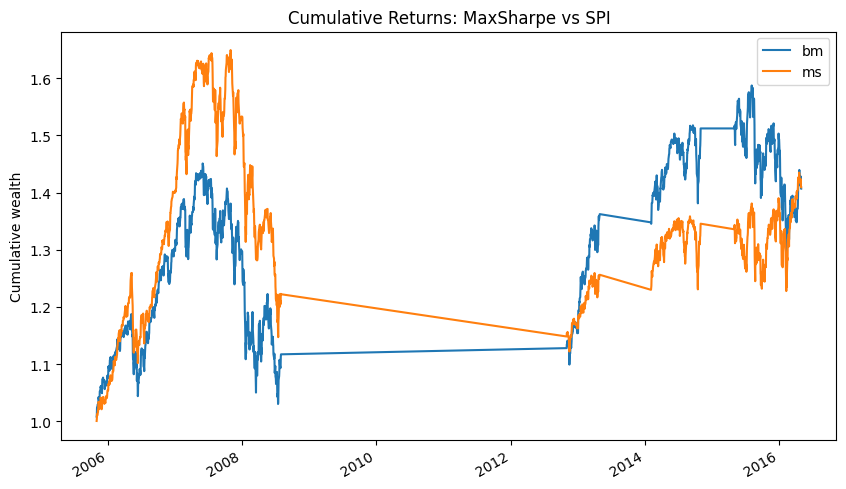

In [ ]:
# Plot the cumulative returns of the strategy and the benchmark
cum_sim = (1 + sim).cumprod()
cum_sim.plot(figsize=(10, 6), title="Cumulative Returns: MaxSharpe vs SPI")
plt.ylabel("Cumulative wealth")
plt.show()

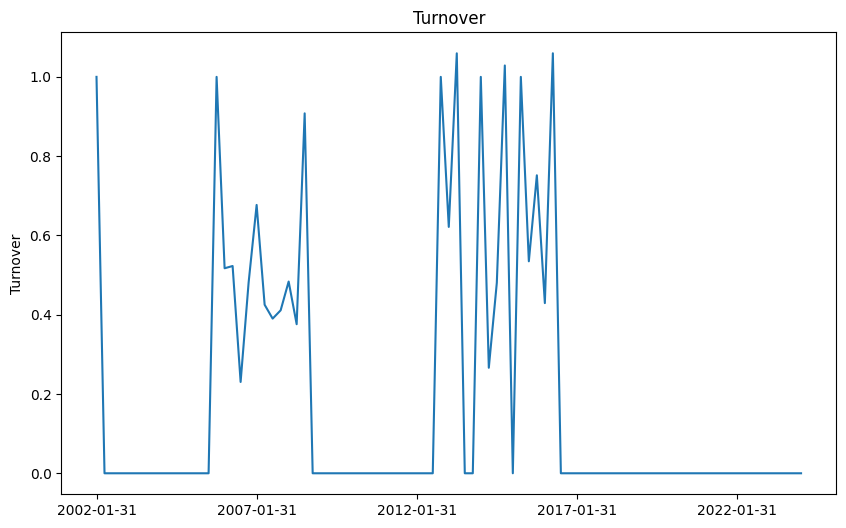

In [ ]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series, rescale=False).dropna()
to_ms.plot(title='Turnover', figsize=(10, 6))
plt.ylabel("Turnover")
plt.show()

In [ ]:
# Annualized turnover per annum (pa) in percentage
to_pa = to_ms.mean() * 4 * 100
print(f"The annualized turnover is: {to_pa:.2f}%")


The annualized turnover is: 74.85%


In [ ]:
# Descriptive statistics

desc = pd.DataFrame({
    "Mean": sim.mean() * 252,
    "Volatility": sim.std() * np.sqrt(252),
    "Sharpe": (sim.mean() / sim.std()) * np.sqrt(252),
    "Skewness": sim.skew(),
    "Excess Kurtosis": sim.kurt(),
    "Min": sim.min(),
    "Max": sim.max(),
})

display(desc)

,Mean,Volatility,Sharpe,Skewness,Excess Kurtosis,Min,Max
bm,0.077029,0.152450,0.505274,-0.291639,2.358416,-0.050811,0.042638
ms,0.075090,0.136648,0.549513,-0.697892,4.051858,-0.060478,0.033548
